---
title: "Tutorial 6 (Advanced): Linking Brain to Phenotypes (Part 3: Machine Learning)"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

# From association to prediction

In Tutorial 5, we asked whether age and functional connectivity (FC) were **associated**. Here, we ask a different question:

> **Can large-scale FC patterns distinguish younger from older adults in participants the model has not seen?**

This is a **supervised machine-learning classification** problem. *Supervised* means that the model learns from examples for which the answer (the age group) is already known. *Classification* means that the answer is a category rather than a continuous number.

By the end of this tutorial, you will be able to:

- identify the **samples**, **features**, and **target** in a neuroscience question;
- explain training data, test data, overfitting, cross-validation, and data leakage;
- build a regularized logistic-regression pipeline;
- compare a model with a simple baseline;
- evaluate classification with balanced accuracy, a confusion matrix, and ROC AUC;
- use a permutation test to ask whether prediction is better than chance; and
- interpret a predictive result without making causal or clinical claims.

```{important}
This tutorial uses the FC matrices from Tutorial 2 and the cleaned metadata and network labels from Tutorial 4. Run those tutorials first. You will also need **scikit-learn** (`conda install scikit-learn` or `pip install scikit-learn`).
```

## The scientific question comes first

Machine learning is a tool, not a research question. Before choosing an algorithm, translate the neuroscience question into three parts:

| Machine-learning term | Meaning here |
|---|---|
| **Samples** | participants |
| **Features (`X`)** | 28 within- and between-network FC summaries per participant |
| **Target (`y`)** | younger (`0`) or older (`1`) age group |

The LEMON metadata contains age **bins**, not exact ages. Tutorial 4 grouped participants below 40 as younger and participants aged 55 or above as older; there are no participants aged 40–54 in these data. Our model therefore classifies two sampled cohorts. It does **not** estimate a continuous “brain age,” and it cannot tell us how it would perform in middle-aged adults.

Our workflow will be:

> FC matrices → network-level features → cross-validation → held-out predictions → scientific interpretation

In [1]:
# Imports and project paths

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    permutation_test_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# Option 1: use the current working directory if the notebook is inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path(
    "/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026"
)

RESULTS_DIR = PROJECT_DIR / "results"
PROCESSED_DIR = PROJECT_DIR / "processed_data"

In [2]:
# Load the outputs created in Tutorials 2 and 4

required_files = {
    "FC matrices": RESULTS_DIR / "subject_fc_stack.npy",
    "participant IDs": RESULTS_DIR / "subject_ids.npy",
    "region names": RESULTS_DIR / "region_names.npy",
    "cleaned metadata": PROCESSED_DIR / "lemon_analysis_metadata.csv",
    "network indices": PROCESSED_DIR / "network_region_indices.npy",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Some required files are missing. Run Tutorials 2 and 4 first, and check "
        f"PROJECT_DIR. Missing files: {missing_files}"
    )

fc_stack = np.load(required_files["FC matrices"])
subject_ids = np.load(required_files["participant IDs"], allow_pickle=True).astype(str)
region_names = np.load(required_files["region names"], allow_pickle=True).astype(str)
analysis_meta = pd.read_csv(required_files["cleaned metadata"])
loaded_network_indices = np.load(required_files["network indices"], allow_pickle=True).item()
net_to_idx = {str(name): np.asarray(indices) for name, indices in loaded_network_indices.items()}

print(f"FC array: {fc_stack.shape}  (participants × regions × regions)")
print(f"Metadata: {analysis_meta.shape}")
print(f"Networks: {list(net_to_idx)}")

FC array: (220, 100, 100)  (participants × regions × regions)
Metadata: (220, 12)
Networks: ['Visual', 'SMN', 'DAN', 'VAN', 'Limbic', 'FPN', 'DMN']


## 1. Audit the data before modelling

A model will often run even when rows are misaligned. That makes alignment checks scientifically essential: participant 1's FC matrix must be paired with participant 1's age label.

In [ ]:
# Check that all files refer to participants in exactly the same order

metadata_ids = analysis_meta["subject_id"].astype(str).to_numpy()

# An assert statement checks if a condition in your code is true, 
# and if it is false, it stops the program by raising an error
assert len(fc_stack) == len(subject_ids) == len(analysis_meta)
assert np.array_equal(subject_ids, metadata_ids)
assert fc_stack.shape[1] == fc_stack.shape[2] == len(region_names)

print("Alignment checks passed.")

Alignment checks passed.


In [ ]:
# Inspect the target or dependent variable (age) and any missing value

print("Age-group counts (including missing values):")
display(analysis_meta["age_group"].value_counts(dropna=False).rename("participants"))

usable_meta = analysis_meta[analysis_meta["age_group"].isin(["Young", "Old"])]

print("\nSex composition within each age group:")
display(pd.crosstab(usable_meta["age_group"], usable_meta["sex"], normalize="index").round(3))

Age-group counts (including missing values):


age_group
Young    151
Old       68
NaN        1
Name: participants, dtype: int64


Sex composition within each age group:


sex,Female,Male
age_group,,
Old,0.471,0.529
Young,0.298,0.702


One participant has no age-group label, so we will exclude that participant when we construct `X` and `y`. As you can see, checking our data carefully is very important. 

The sex proportions also differ between age groups. This does not invalidate the exercise, but it creates a possible **confound**: some FC patterns used by the classifier could be related to sex as well as age group. We will return to this limitation when interpreting the model.

## 2. Turn connectomes into features

Each 100 × 100 symmetric FC matrix contains 4,950 unique edges. We could either use ALL the unique edges as "features" that we feed into the machine learning model. Or, we can use our mean within-network and between-network FC values as features to predict the model. 

For now, let's use the **28 interpretable network features** for our model:


- 7 mean within-network FC values; and
- 21 mean between-network FC values (every pair among 7 networks).

Before averaging correlations, we apply the **Fisher *z* transformation** introduced earlier. Pearson correlations are bounded between −1 and +1 and have a skewed sampling distribution near those limits. Fisher *z* values are more suitable for averaging and modelling.

```{note}
This feature design is a scientific choice. It improves interpretability and reduces dimensionality, but it may discard informative individual edges. More features are not automatically better.
```

In [5]:
# Fisher z-transform each participant's FC matrix

# Clipping prevents infinite values if numerical rounding produces exactly -1 or +1.
z_fc_stack = np.arctanh(np.clip(fc_stack, -0.999999, 0.999999))

network_names = list(net_to_idx)
feature_data = {}

# Seven within-network features. We use the upper triangle so that each edge is
# counted once and the diagonal (a region correlated with itself) is excluded.
for network in network_names:
    indices = np.asarray(net_to_idx[network])
    block = z_fc_stack[:, indices[:, None], indices[None, :]]
    upper = np.triu_indices(len(indices), k=1)
    feature_data[f"{network} within"] = block[:, upper[0], upper[1]].mean(axis=1)

# Twenty-one between-network features
for network_a, network_b in combinations(network_names, 2):
    indices_a = np.asarray(net_to_idx[network_a])
    indices_b = np.asarray(net_to_idx[network_b])
    block = z_fc_stack[:, indices_a[:, None], indices_b[None, :]]
    feature_data[f"{network_a}–{network_b}"] = block.mean(axis=(1, 2))

feature_df = pd.DataFrame(feature_data, index=subject_ids)

print(f"Feature table: {feature_df.shape[0]} participants × {feature_df.shape[1]} features")
display(feature_df.head())

Feature table: 220 participants × 28 features


,Visual within,SMN within,DAN within,VAN within,Limbic within,FPN within,DMN within,Visual–SMN,Visual–DAN,Visual–VAN,...,DAN–VAN,DAN–Limbic,DAN–FPN,DAN–DMN,VAN–Limbic,VAN–FPN,VAN–DMN,Limbic–FPN,Limbic–DMN,FPN–DMN
sub-010002,0.554779,0.352086,0.464045,0.520293,0.445534,0.447956,0.581784,0.202107,0.215025,0.248702,...,0.343796,0.133319,0.260103,0.108935,-0.043792,0.119150,-0.086467,0.295524,0.408054,0.312074
sub-010003,0.706880,0.718268,0.801581,0.576414,0.628380,0.457207,0.562480,0.394337,0.501957,0.264876,...,0.377402,0.193565,0.439461,0.149229,0.109112,0.225413,0.101217,0.222850,0.464160,0.314418
sub-010004,0.880350,1.111750,0.532303,1.006087,0.521755,0.385237,0.407310,0.392440,0.431982,0.528436,...,0.523610,0.238724,0.238931,0.157811,0.285416,0.289268,0.159413,0.201821,0.366773,0.153474
sub-010005,0.994483,1.226059,0.969323,0.808755,0.967577,0.718074,0.695631,0.689396,0.752375,0.493310,...,0.654000,0.294603,0.455569,0.339854,0.390425,0.463194,0.444814,0.470247,0.684323,0.575035
sub-010006,0.645406,1.102473,0.805499,0.811506,0.696911,0.845792,0.676291,0.302875,0.438020,0.499456,...,0.592793,0.484886,0.287016,0.339273,0.488865,0.587455,0.393961,0.476834,0.585582,0.545378


In [6]:
# Build X (features) and y (target), excluding the missing target

valid_age = analysis_meta["age_group"].isin(["Young", "Old"]).to_numpy()

X = feature_df.to_numpy()[valid_age]
y = (analysis_meta.loc[valid_age, "age_group"] == "Old").astype(int).to_numpy()
model_subject_ids = subject_ids[valid_age]

assert len(X) == len(y) == len(model_subject_ids)
assert np.isfinite(X).all()

class_table = pd.DataFrame(
    {
        "class label": [0, 1],
        "age group": ["Younger", "Older"],
        "participants": np.bincount(y),
    }
)
display(class_table)

,class label,age group,participants
0,0,Younger,151
1,1,Older,68


### Pause and predict

The classes are unequal: there are more younger than older participants.

1. If a model predicts “younger” for everyone, what accuracy would it obtain?
2. Would that model have learned anything about FC?
3. Which result would convince you that a model can generalize: its score on data used to fit it, or its score on unseen data?

Keep your answers in mind. We will test them below.

## 3. Training, testing, and overfitting

A model **fits** (learns its coefficients) from training participants. We then evaluate it on test participants that were not used to fit that version of the model.

If we fit and evaluate on the same people, the model can learn patterns specific to this sample. Excellent training performance may therefore coexist with poor performance on new participants. This is **overfitting**.

We will use **5-fold stratified cross-validation**:

1. divide participants into five folds while preserving approximately the same young/old proportion in each fold;
2. fit on four folds and test on the remaining fold;
3. repeat until every fold has served as the test set once; and
4. summarize performance across the five held-out folds.

Cross-validation estimates performance on unseen participants from this sampled population. It is **not** the same as validating the model in a new dataset, scanner, or site.

### Data leakage: an important consideration in ML

**Test data must not influence model fitting or model choices.** Leakage makes a model appear more generalizable than it is.

We need to standardize each feature because connectivity features have different spreads. However, calculating a mean and standard deviation using the full dataset would allow information from each test fold to leak into training. A scikit-learn **pipeline** prevents this: within every fold, it fits the scaler on the training participants and applies that fitted scaler to the test participants.

Creating our 28 FC summaries before cross-validation is safe here because each summary uses only that participant's FC matrix and a predefined atlas—never the target labels or other participants.

## 4. Choose a model and a baseline

We will use **logistic regression**. Despite its name, logistic regression is a classifier. It combines the features into a score and converts that score into an estimated probability of the older group.

We also use:

- **L2 regularization**, which discourages very large coefficients and reduces overfitting;
- `class_weight="balanced"`, which gives the smaller older group more weight while fitting; and
- a **dummy baseline** that always predicts the most common class.

The baseline answers a basic question: *does the FC model do more than exploit the class imbalance?*

In [7]:
# Define the complete modelling pipeline and cross-validation plan

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,                 # inverse regularization strength; fixed in advance
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
    ),
)

baseline = DummyClassifier(strategy="most_frequent")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

We fix the model and its settings before examining test performance. Trying many settings and reporting the one with the best score on these same test folds would make those folds part of model selection. Comparing tuned models honestly requires **nested cross-validation**, an advanced extension suggested at the end.

## 5. Evaluate generalization

No single metric tells the whole story:

- **Accuracy** is the fraction of all participants classified correctly. It can be misleading when classes are unequal.
- **Balanced accuracy** is the average of the correct-classification rate for younger and older adults. Chance is 0.50 for a binary problem, even when group sizes differ.
- **ROC AUC** measures how well predicted probabilities rank older participants above younger participants across every possible threshold. Chance is 0.50; 1.00 is perfect ranking.

We will treat **balanced accuracy as the primary metric** because the groups are unequal, while also reporting accuracy and ROC AUC.

In [8]:
# Run the same five folds for the FC model and the dummy baseline

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
}

model_cv = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
)

baseline_cv = cross_validate(
    baseline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
)

def summarize_cv(result, label):
    """Return one tidy row of held-out cross-validation results."""
    return {
        "model": label,
        "balanced accuracy (mean)": result["test_balanced_accuracy"].mean(),
        "balanced accuracy (SD)": result["test_balanced_accuracy"].std(ddof=1),
        "ROC AUC (mean)": result["test_roc_auc"].mean(),
        "accuracy (mean)": result["test_accuracy"].mean(),
    }

cv_summary = pd.DataFrame(
    [
        summarize_cv(model_cv, "FC logistic regression"),
        summarize_cv(baseline_cv, "Most-common-class baseline"),
    ]
)

display(cv_summary.round(3))

,model,balanced accuracy (mean),balanced accuracy (SD),ROC AUC (mean),accuracy (mean)
0,FC logistic regression,0.735,0.02,0.791,0.744
1,Most-common-class baseline,0.500,0.00,0.500,0.690


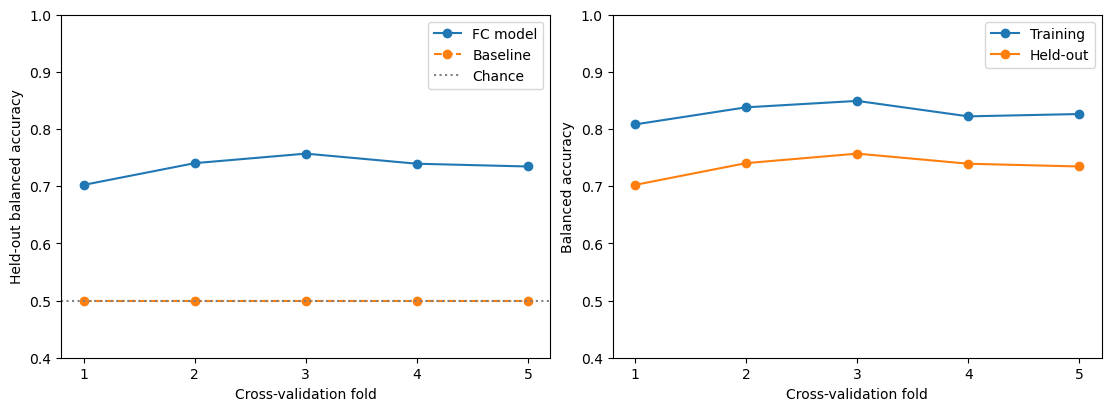

In [9]:
# Inspect variation across folds and the train-test gap

folds = np.arange(1, cv.get_n_splits() + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(folds, model_cv["test_balanced_accuracy"], "o-", label="FC model")
axes[0].plot(folds, baseline_cv["test_balanced_accuracy"], "o--", label="Baseline")
axes[0].axhline(0.5, color="grey", linestyle=":", label="Chance")
axes[0].set(
    xlabel="Cross-validation fold",
    ylabel="Held-out balanced accuracy",
    xticks=folds,
    ylim=(0.4, 1.0),
)
axes[0].legend()

axes[1].plot(folds, model_cv["train_balanced_accuracy"], "o-", label="Training")
axes[1].plot(folds, model_cv["test_balanced_accuracy"], "o-", label="Held-out")
axes[1].set(
    xlabel="Cross-validation fold",
    ylabel="Balanced accuracy",
    xticks=folds,
    ylim=(0.4, 1.0),
)
axes[1].legend()

plt.show()

You should find that the FC model's held-out balanced accuracy is around **0.73**, compared with **0.50** for the baseline. Its ordinary accuracy is around 0.74, while the baseline already obtains about 0.69 by always predicting the larger younger group. This is exactly why balanced accuracy matters.

Training performance is higher than held-out performance. That gap is evidence of some overfitting, even though regularization and low-dimensional features help control it. Report the held-out results—not the training scores—as the estimate of generalization.

## 6. Examine out-of-fold predictions

`cross_val_predict` gives each participant a prediction from the fold in which that participant was held out. Thus, every plotted prediction below comes from a model that was not fitted on that participant.

accuracy             0.744
balanced accuracy    0.734
ROC AUC              0.796
Name: out-of-fold result, dtype: float64

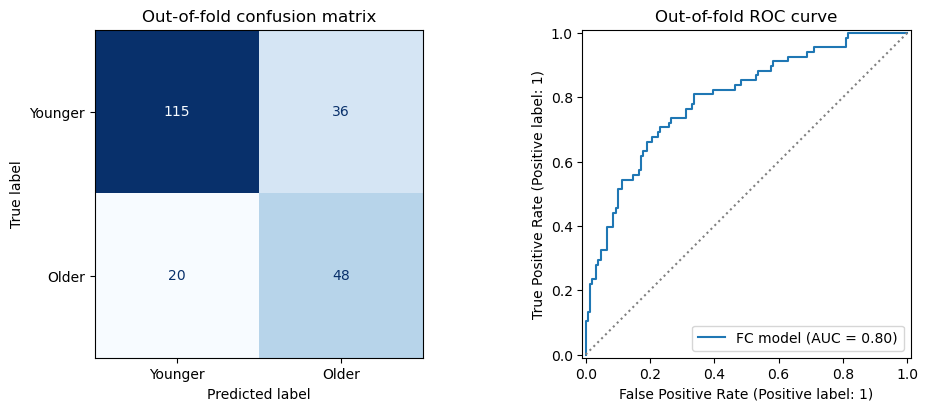

In [10]:
# Obtain one out-of-fold probability for every participant

oof_probability = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba",
)[:, 1]

oof_prediction = (oof_probability >= 0.5).astype(int)

oof_metrics = pd.Series(
    {
        "accuracy": accuracy_score(y, oof_prediction),
        "balanced accuracy": balanced_accuracy_score(y, oof_prediction),
        "ROC AUC": roc_auc_score(y, oof_probability),
    },
    name="out-of-fold result",
)
display(oof_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y, oof_prediction),
    display_labels=["Younger", "Older"],
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Out-of-fold confusion matrix")

RocCurveDisplay.from_predictions(y, oof_probability, ax=axes[1], name="FC model")
axes[1].plot([0, 1], [0, 1], linestyle=":", color="grey", label="Chance")
axes[1].set_title("Out-of-fold ROC curve")

plt.show()

Read the confusion matrix by **rows** (true group) and then **columns** (predicted group). In this run, the model correctly classifies most participants but makes errors in both groups. An ROC AUC around 0.80 means that an older participant tends to receive a higher model score than a younger participant; it does not mean that 80% of individuals are classified correctly.

The probability threshold of 0.50 converts scores into class labels. Changing it trades one type of error for another. Choosing a threshold should depend on the scientific or practical cost of those errors, not on which threshold makes the current results look best.

## 7. Is performance better than chance?

A **permutation test** asks what scores we would obtain if age labels were unrelated to FC. We repeatedly shuffle `y`, rerun the entire cross-validation procedure, and compare those scores with the real-label score.

Our null hypothesis is:

> Network-level FC contains no more age-group information than expected from randomly assigned labels under this evaluation procedure.

We use 500 permutations to keep the tutorial quick. A research project may use more permutations for a more precise *p*-value.

Observed balanced accuracy: 0.735
Permutation p-value: 0.0020


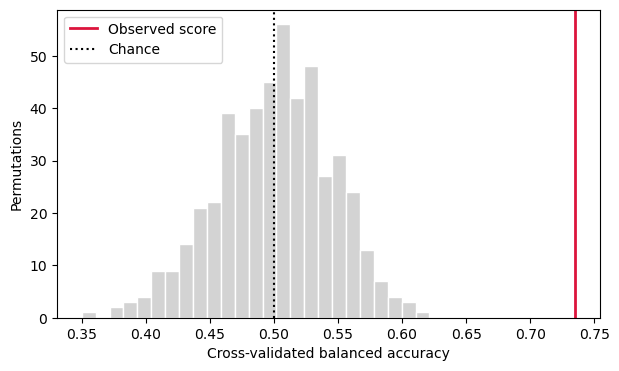

In [11]:
# This cell may take several seconds because it refits many models.

observed_score, permuted_scores, permutation_p = permutation_test_score(
    model,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy",
    n_permutations=500,
    random_state=42,
    n_jobs=1,
)

print(f"Observed balanced accuracy: {observed_score:.3f}")
print(f"Permutation p-value: {permutation_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(permuted_scores, bins=25, color="lightgrey", edgecolor="white")
ax.axvline(observed_score, color="crimson", linewidth=2, label="Observed score")
ax.axvline(0.5, color="black", linestyle=":", label="Chance")
ax.set(xlabel="Cross-validated balanced accuracy", ylabel="Permutations")
ax.legend()
plt.show()

The small permutation *p*-value indicates that the observed cross-validated performance is unlikely under randomly shuffled age labels. It does **not** prove that ageing causes these FC patterns, that the model is clinically useful, or that it will generalize to another dataset.

## 8. Which features influenced the classifier?

Because every input feature is standardized inside the pipeline, logistic-regression coefficients are on a comparable scale:

- a **positive** coefficient contributes toward the older-group prediction;
- a **negative** coefficient contributes toward the younger-group prediction; and
- a coefficient farther from zero has more influence *conditional on the other features*.

Rather than interpreting one model fitted to everybody, we collect coefficients from the five training folds. This lets us see whether their direction and magnitude are reasonably stable across resamples.

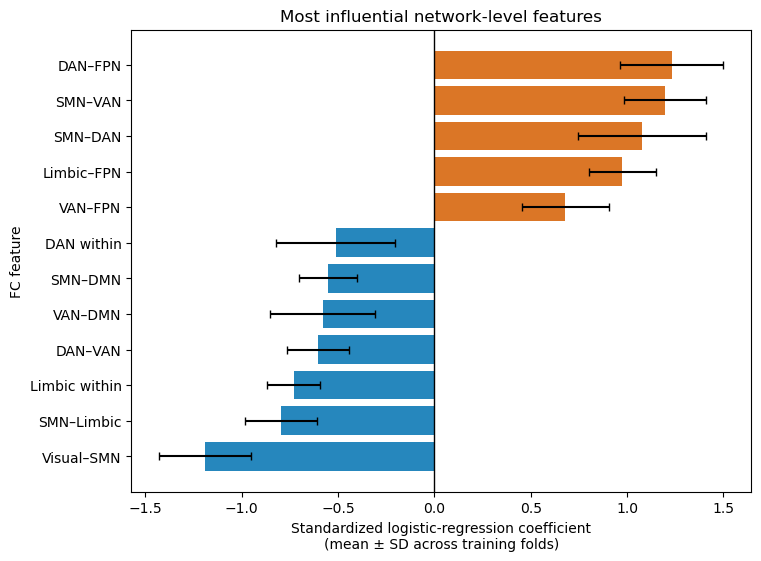

,mean coefficient,SD across folds
DAN–FPN,1.231,0.267
SMN–VAN,1.197,0.215
Visual–SMN,-1.189,0.237
SMN–DAN,1.078,0.333
Limbic–FPN,0.975,0.173
SMN–Limbic,-0.795,0.186
Limbic within,-0.730,0.137
VAN–FPN,0.679,0.226
DAN–VAN,-0.604,0.159
VAN–DMN,-0.579,0.271


In [12]:
# Fit the pipeline separately in each training fold and retain its coefficients

fold_coefficients = []

for train_index, test_index in cv.split(X, y):
    model.fit(X[train_index], y[train_index])
    coefficients = model.named_steps["logisticregression"].coef_[0]
    fold_coefficients.append(coefficients)

coefficient_df = pd.DataFrame(
    fold_coefficients,
    columns=feature_df.columns,
    index=[f"Fold {fold}" for fold in folds],
)

coefficient_summary = pd.DataFrame(
    {
        "mean coefficient": coefficient_df.mean(),
        "SD across folds": coefficient_df.std(ddof=1),
    }
)
coefficient_summary["absolute mean"] = coefficient_summary["mean coefficient"].abs()
coefficient_summary = coefficient_summary.sort_values("absolute mean", ascending=False)

top_features = coefficient_summary.head(12).sort_values("mean coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(top_features["mean coefficient"] > 0, "#D55E00", "#0072B2")
ax.barh(
    top_features.index,
    top_features["mean coefficient"],
    xerr=top_features["SD across folds"],
    color=colors,
    alpha=0.85,
    capsize=3,
)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    xlabel="Standardized logistic-regression coefficient\n(mean ± SD across training folds)",
    ylabel="FC feature",
    title="Most influential network-level features",
)
plt.show()

display(coefficient_summary.drop(columns="absolute mean").head(12).round(3))

### Interpret coefficients carefully

The strongest coefficients suggest which distributed FC patterns the classifier used. They are **not** isolated biological effects:

- FC features are correlated, so one coefficient can change when another feature is added or removed.
- Regularization deliberately shrinks coefficients.
- The bars are not confidence intervals or tests of statistical significance.
- Prediction does not establish that age caused the pattern.
- Because sex composition differs across the age groups, some learned signal could reflect sex-related FC variation.

A defensible statement is:

> “Several network-level FC features contributed consistently to out-of-fold age-group classification in this sample.”

An overclaim would be:

> “These connections are biomarkers that cause brain ageing.”

## 9. Think like a neuroscientist

Before writing the Discussion, answer these questions:

1. **What is being predicted?** Two non-adjacent age cohorts—not exact age and not a lifespan trajectory.
2. **What biological information is retained?** Mean coupling within and between seven canonical networks.
3. **What information is discarded?** Individual edges, spatial variation within a network, dynamics over time, and non-FC measures.
4. **Could the model use a shortcut?** Age-group differences in sex composition, motion, data quality, or other unmeasured variables could contribute.
5. **Where should it generalize?** At most, to similar healthy participants measured and processed in similar ways until external validation is performed.
6. **What does this add to our understanding of ageing?** Above-chance prediction shows that distributed network-level FC contains information that distinguishes the sampled younger and older cohorts. The coefficient analysis identifies candidate coupling patterns used by the model, but it does not show that these patterns are caused by ageing or change within individuals. Those possibilities require targeted, confound-controlled, and ideally longitudinal or externally validated follow-up studies.

These questions are as important as the code. It helps contextualize your results in our understanding of the brain. 

## 10. Reporting the analysis

A concise Methods description could read:

> For each participant, Pearson-correlation FC matrices were Fisher *z*-transformed and summarized as seven within-network and 21 between-network mean-connectivity features. One participant without an age-group label was excluded. A pipeline standardized features within each training fold and fitted an L2-regularized logistic-regression classifier with balanced class weights. Performance was assessed using five-fold stratified cross-validation with a fixed random seed. Balanced accuracy was the primary metric; accuracy and ROC AUC were secondary metrics. Performance was compared with a most-common-class baseline and evaluated using a 500-permutation label test.

Report the participant counts, all model settings, fold strategy, random seed, mean and variability across folds, baseline, permutation count and *p*-value, and every exclusion. Do not report only the best fold.

## 11. Limitations of this demonstration

- This is a small, single-dataset analysis without external validation.
- The sampled cohorts are imbalanced and separated by an age gap.
- The target uses broad age bins rather than exact ages.
- Sex composition differs between groups; motion and other confounds also require investigation.
- Cross-validation folds are not fully independent because their training sets overlap.
- The 28 network averages improve interpretability but remove edge-level information.
- Feature coefficients are descriptive model parameters, not causal estimates or corrected hypothesis tests.
- A statistically convincing score is not automatically a useful or ethical biomarker.

## 12. Extend the analysis

Choose an extension because it answers a scientific question—not merely because another algorithm is available.

### Starting Point

1. Change the random seed in `StratifiedKFold`. How stable are the mean and fold-to-fold scores?
2. Remove `class_weight="balanced"`. Which class is most affected in the confusion matrix?
3. Use a continuous phenotype such as `Hamilton_Scale` as the target. This becomes a **regression** problem: remove missing targets, use `Ridge` rather than logistic regression, and evaluate held-out mean absolute error and $R^2$.

### Intermediate

4. Compare network-level features with all 4,950 unique edges. Look at the literature what ML techniques do people normally use for FC. See https://nilearn.github.io/stable/auto_examples/07_advanced/plot_age_group_prediction_cross_val.html 
5. Ask whether FC adds predictive information beyond sex. Build and evaluate a demographic-only model and an FC-plus-demographic model using the same folds. Be precise: this comparison still does not “remove” every confound.
6. Repeat cross-validation with several seeds and visualize the distribution of scores rather than relying on one partition.

### Advanced

7. Tune the regularization strength `C` using **nested cross-validation**: select `C` only inside each outer training fold, then evaluate once on its untouched outer test fold.
8. Use graph theories measures as features to predict a phenotype! Look at the literature for inspiration. 

# Tutorial summary

You have now completed an example of using ML to link brain and phenotypes:

1. start with a neuroscience question;
2. define participants, features, and target;
3. audit alignment, missingness, imbalance, and possible confounds;
4. reduce FC matrices to interpretable network features;
5. keep preprocessing inside a pipeline to prevent leakage;
6. estimate generalization with stratified cross-validation;
7. compare against a meaningful baseline and chance distribution;
8. inspect errors and model coefficients cautiously; and
9. state exactly what the data can and cannot support.